In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
data=pd.read_csv("./data/wine_train.csv")
data

,와인_종류,알코올_도수,사과산_함량,재_함량,재의_알칼리도,마그네슘_함량,총_페놀_함량,플라보노이드_함량,비플라보노이드_페놀_함량,프로안토시아닌_함량,색_강도,색조,희석_와인의_투과율_OD280_OD315,프롤린_함량
0,1,13.76,1.53,2.70,19.5,132,2.95,2.74,0.50,1.35,5.40,1.25,3.00,1235
1,2,12.67,0.98,2.24,18.0,99,2.20,1.94,0.30,1.46,2.62,1.23,3.16,450
2,1,13.58,1.66,2.36,19.1,106,2.86,3.19,0.22,1.95,6.90,1.09,2.88,1515
3,2,13.86,1.51,2.67,25.0,86,2.95,2.86,0.21,1.87,3.38,1.36,3.16,410
4,1,13.05,2.05,3.22,25.0,124,2.63,2.68,0.47,1.92,3.58,1.13,3.20,830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,2,12.43,1.53,2.29,21.5,86,2.74,3.15,0.39,1.77,3.94,0.69,2.84,352
102,3,12.20,3.03,2.32,19.0,96,1.25,0.49,0.40,0.73,5.50,0.66,1.83,510
103,1,13.51,1.80,2.65,19.0,110,2.35,2.53,0.29,1.54,4.20,1.10,2.87,1095
104,2,12.70,3.87,2.40,23.0,101,2.83,2.55,0.43,1.95,2.57,1.19,3.13,463


In [3]:
data['와인_종류'].value_counts()

와인_종류
2    42
1    35
3    29
Name: count, dtype: int64

<Axes: >

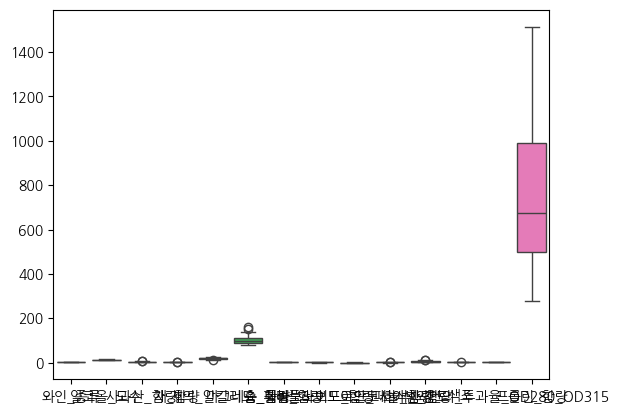

In [4]:
sns.boxplot(data)

<Axes: >

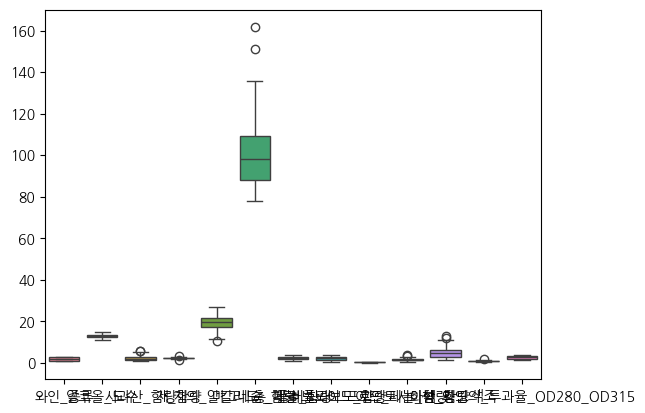

In [5]:
sns.boxplot(data.iloc[:,:-1])

<Axes: >

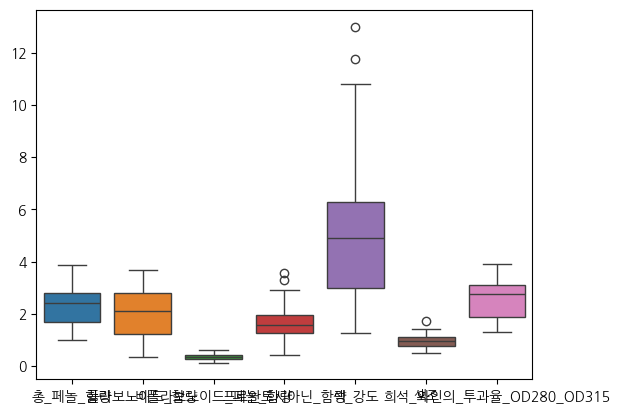

In [6]:
sns.boxplot(data.iloc[:, 6:-1])

In [7]:
data.columns

Index(['와인_종류', '알코올_도수', '사과산_함량', '재_함량', '재의_알칼리도', '마그네슘_함량', '총_페놀_함량',
       '플라보노이드_함량', '비플라보노이드_페놀_함량', '프로안토시아닌_함량', '색_강도', '색조',
       '희석_와인의_투과율_OD280_OD315', '프롤린_함량'],
      dtype='object')

In [8]:
data['프롤린_함량'].value_counts()

프롤린_함량
450     3
510     3
750     3
680     3
625     3
       ..
985     1
352     1
1095    1
463     1
672     1
Name: count, Length: 79, dtype: int64

In [9]:
data['프롤린_함량'].nunique()

79

In [10]:
X=data.drop('와인_종류', axis=1)
y=data['와인_종류']

In [11]:
y=pd.get_dummies(y)

In [12]:
y

,1,2,3
0,True,False,False
1,False,True,False
2,True,False,False
3,False,True,False
4,True,False,False
...,...,...,...
101,False,True,False
102,False,False,True
103,True,False,False
104,False,True,False


In [13]:
data['와인_종류'].value_counts()

와인_종류
2    42
1    35
3    29
Name: count, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [16]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler


mms = MinMaxScaler()
X_train_temp = mms.fit_transform(X_train)
X_test_temp = mms.transform(X_test)
mms_X_train=pd.DataFrame(X_train_temp, columns=X_train.columns, index=X_train.index)
mms_X_test=pd.DataFrame(X_test_temp, columns=X_test.columns, index=X_test.index)

# mms 변수에 있는 MinMaxScaler 가중치 저장방법:joblib
* joblib.dump(경로, 파일명)
* joblib.load(경로, 파일명)

In [26]:
import joblib

In [27]:
joblib.dump(mms, "./model/MinMax_info.joblib")

['./model/MinMax_info.joblib']

In [17]:
X_test

,알코올_도수,사과산_함량,재_함량,재의_알칼리도,마그네슘_함량,총_페놀_함량,플라보노이드_함량,비플라보노이드_페놀_함량,프로안토시아닌_함량,색_강도,색조,희석_와인의_투과율_OD280_OD315,프롤린_함량
68,12.08,1.39,2.50,22.5,84,2.56,2.29,0.43,1.04,2.900000,0.930,3.19,385
36,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.320000,1.040,2.93,735
78,13.50,3.12,2.62,24.0,123,1.40,1.57,0.22,1.25,8.600000,0.590,1.30,500
63,12.29,1.61,2.21,20.4,103,1.10,1.02,0.37,1.46,3.050000,0.906,1.82,870
19,11.46,3.74,1.82,19.5,107,3.18,2.58,0.24,3.58,2.900000,0.750,2.81,562
37,11.03,1.51,2.20,21.5,85,2.46,2.17,0.52,2.01,1.900000,1.710,2.87,407
40,12.29,3.17,2.21,18.0,88,2.85,2.99,0.45,2.81,2.300000,1.420,2.83,406
60,14.21,4.04,2.44,18.9,111,2.85,2.65,0.30,1.25,5.240000,0.870,3.33,1080
90,14.22,1.70,2.30,16.3,118,3.20,3.00,0.26,2.03,6.380000,0.940,3.31,970
8,12.25,1.73,2.12,19.0,80,1.65,2.03,0.37,1.63,3.400000,1.000,3.17,510


In [18]:
X_train

,알코올_도수,사과산_함량,재_함량,재의_알칼리도,마그네슘_함량,총_페놀_함량,플라보노이드_함량,비플라보노이드_페놀_함량,프로안토시아닌_함량,색_강도,색조,희석_와인의_투과율_OD280_OD315,프롤린_함량
58,14.12,1.48,2.32,16.8,95,2.20,2.43,0.26,1.57,5.00,1.17,2.82,1280
13,12.85,3.27,2.58,22.0,106,1.65,0.60,0.60,0.96,5.58,0.87,2.11,570
53,13.83,1.57,2.62,20.0,115,2.95,3.40,0.40,1.72,6.60,1.13,2.57,1130
9,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045
6,12.58,1.29,2.10,20.0,103,1.48,0.58,0.53,1.40,7.60,0.58,1.55,640
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,13.69,3.26,2.54,20.0,107,1.83,0.56,0.50,0.80,5.88,0.96,1.82,680
105,12.51,1.73,1.98,20.5,85,2.20,1.92,0.32,1.48,2.94,1.04,3.57,672
94,11.45,2.40,2.42,20.0,96,2.90,2.79,0.32,1.83,3.25,0.80,3.39,625
47,12.79,2.67,2.48,22.0,112,1.48,1.36,0.24,1.26,10.80,0.48,1.47,480


In [19]:
y_train=pd.get_dummies(y_train)
y_test=pd.get_dummies(y_test)

In [20]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping, ModelCheckpoint

2025-05-15 16:38:29.693354: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-15 16:38:29.726139: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747294709.771714   59684 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747294709.782984   59684 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747294709.815234   59684 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [24]:
model=Sequential()
model.add(Input(shape=(mms_X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,555 (13.89 KB)

 Trainable params: 3,555 (13.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000


I0000 00:00:1747295281.014992   59735 service.cc:152] XLA service 0x7effbc00a750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747295281.015127   59735 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-15 16:48:01.134549: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747295281.690724   59735 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/5 ━━━━━━━━━━━━━━━━━━━━ 26s 7s/step - accuracy: 0.1250 - loss: 1.1144

I0000 00:00:1747295285.372038   59735 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.2345 - loss: 1.0953 - val_accuracy: 0.4375 - val_loss: 1.0502
Epoch 2/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5568 - loss: 1.0291 - val_accuracy: 0.5938 - val_loss: 1.0038
Epoch 3/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6084 - loss: 0.9924 - val_accuracy: 0.6250 - val_loss: 0.9629
Epoch 4/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7220 - loss: 0.9558 - val_accuracy: 0.7812 - val_loss: 0.9222
Epoch 5/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8460 - loss: 0.8923 - val_accuracy: 0.8125 - val_loss: 0.8788
Epoch 6/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8727 - loss: 0.8378 - val_accuracy: 0.8125 - val_loss: 0.8328
Epoch 7/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9367 - loss: 0.7937 - val_accuracy: 0.8438 - val_loss: 0.7852
Epoch 8/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9349 - loss: 0.7191 - val_accuracy: 0.8750 - val_loss: 0.725

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9688 - val_loss: 0.0378
Epoch 152/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9688 - val_loss: 0.0373
Epoch 153/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9688 - val_loss: 0.0391
Epoch 154/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9688 - val_loss: 0.0381
Epoch 155/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9688 - val_loss: 0.0374
Epoch 156/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9688 - val_loss: 0.0374
Epoch 157/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9688 - val_loss: 0.0368
Epoch 158/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9688 - 

Epoch 201/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 6.6007e-04 - val_accuracy: 0.9688 - val_loss: 0.0363
Epoch 202/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 1.0000 - loss: 7.8178e-04 - val_accuracy: 0.9688 - val_loss: 0.0355
Epoch 203/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 1.0000 - loss: 7.9970e-04 - val_accuracy: 0.9688 - val_loss: 0.0349
Epoch 204/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 8.7904e-04 - val_accuracy: 0.9688 - val_loss: 0.0354
Epoch 205/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 1.0000 - loss: 7.0142e-04 - val_accuracy: 0.9688 - val_loss: 0.0360
Epoch 206/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 8.8571e-04 - val_accuracy: 0.9688 - val_loss: 0.0357
Epoch 207/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 8.5122e-04 - val_accuracy: 0.9688 - val_loss: 0.0365
Epoch 208/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 1.00

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 1.0000 - loss: 5.4582e-04 - val_accuracy: 0.9688 - val_loss: 0.0374
Epoch 251/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 1.0000 - loss: 4.1716e-04 - val_accuracy: 0.9688 - val_loss: 0.0374
Epoch 252/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 4.7459e-04 - val_accuracy: 0.9688 - val_loss: 0.0368
Epoch 253/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 5.5514e-04 - val_accuracy: 0.9688 - val_loss: 0.0376
Epoch 254/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 1.0000 - loss: 4.0377e-04 - val_accuracy: 0.9688 - val_loss: 0.0377
Epoch 255/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 5.5127e-04 - val_accuracy: 0.9688 - val_loss: 0.0372
Epoch 256/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 1.0000 - loss: 4.6540e-04 - val_accuracy: 0.9688 - val_loss: 0.0366
Epoch 257/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 5.55

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 3.2787e-04 - val_accuracy: 0.9688 - val_loss: 0.0359
Epoch 300/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 3.6712e-04 - val_accuracy: 0.9688 - val_loss: 0.0362
Epoch 301/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 3.5176e-04 - val_accuracy: 0.9688 - val_loss: 0.0369
Epoch 302/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 3.1903e-04 - val_accuracy: 0.9688 - val_loss: 0.0362
Epoch 303/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 2.7268e-04 - val_accuracy: 0.9688 - val_loss: 0.0358
Epoch 304/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 3.4928e-04 - val_accuracy: 0.9688 - val_loss: 0.0355
Epoch 305/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 3.0286e-04 - val_accuracy: 0.9688 - val_loss: 0.0355
Epoch 306/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 1.0000 - loss: 2.71

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 2.3791e-04 - val_accuracy: 0.9688 - val_loss: 0.0361
Epoch 349/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 1.9617e-04 - val_accuracy: 0.9688 - val_loss: 0.0362
Epoch 350/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 1.9369e-04 - val_accuracy: 0.9688 - val_loss: 0.0369
Epoch 351/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 2.3833e-04 - val_accuracy: 0.9688 - val_loss: 0.0371
Epoch 352/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 1.8476e-04 - val_accuracy: 0.9688 - val_loss: 0.0375
Epoch 353/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 2.2997e-04 - val_accuracy: 0.9688 - val_loss: 0.0373
Epoch 354/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 1.0000 - loss: 2.2306e-04 - val_accuracy: 0.9688 - val_loss: 0.0369
Epoch 355/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 2.34

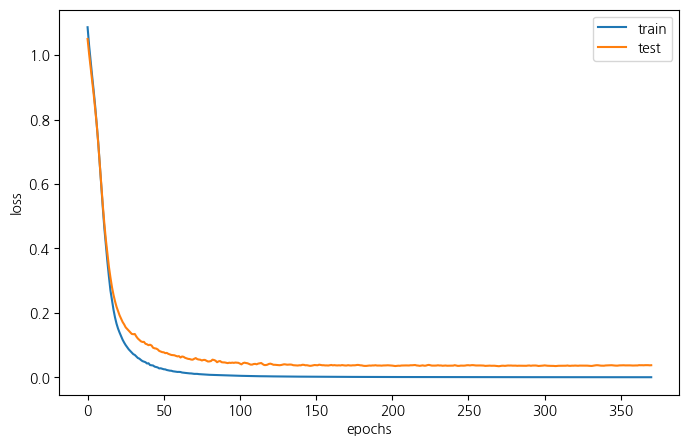

In [25]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
early_stop= EarlyStopping(patience=100)
file_path="./model/wine_best_model.keras"
model_save=ModelCheckpoint(filepath=file_path, save_best_only=True)
history=model.fit(mms_X_train, y_train, epochs=1000, batch_size=16, validation_data=(mms_X_test, y_test),
                 callbacks=[early_stop, model_save])
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train','test'])
plt.show()

In [28]:
import joblib

In [29]:
joblib.dump(mms, "./model/MinMax_info2.joblib")

['./model/MinMax_info2.joblib']

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
rfc=RandomForestClassifier(max_depth=3, n_estimators=500, n_jobs=-1, random_state=42)
rfc.fit(mms_X_train, y_train)
pred=rfc.

In [ ]:
joblib.dump(rfc, "./model/rfc_model.joblib")